# M3.T2 — Tree-Based Model: XGBoost
**Task:** Train XGBoost model for Probability of Default prediction  
**Baseline (Logistic Regression):** ROC-AUC = 0.7149 | Class-1 F1 = 0.41 | Accuracy = 0.75  
**Preprocessing:** Same pipeline as LR notebook (imputation → OHE → scaling)

In [1]:
%pip install xgboost scikit-learn pandas numpy matplotlib statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [3]:
#file_id = "1egYkWM65LIn8Q2rVqVBTa-XjNqaJk2J_"   # old file

file_id = '1ewIyvaTB1T_BVNM5CYNTXrIpPv9kJjK3'   # new file
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

# load data
loan_df = pd.read_csv(url)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 61 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   term                        int64  
 2   int_rate                    float64
 3   installment                 float64
 4   sub_grade                   object 
 5   emp_title                   object 
 6   emp_length                  float64
 7   home_ownership              object 
 8   annual_inc                  float64
 9   verification_status         object 
 10  loan_status                 object 
 11  purpose                     object 
 12  addr_state                  object 
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  inq_last_6mths              float64
 16  open_acc                    float64
 17  pub_rec                     float64
 18  revol_bal                   int64  
 19  revol_util           

In [4]:
print(loan_df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_cur_bal', 'total_bal_il', 'il_util', 'all_util', 'total_rev_hi_lim', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_recent_bc', 'num_accts_ever_120_pd', 'num_actv_rev_tl', 'num_bc_sats', 'num_rev_tl_bal_gt_0', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_il_high_credit_li

## 2. Same Preprocessing as LR Notebook

In [5]:
# Drop same high-cardinality / redundant columns as LR notebook
loan_df = loan_df.drop(columns=['emp_title', 'addr_state'])

# Binary target — same mapping as LR
loan_df = loan_df[loan_df['loan_status'].isin([
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
])]

loan_df['loan_status'] = loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
})

print(f"Shape after filtering: {loan_df.shape}")
print(f"Class distribution:\n{loan_df['loan_status'].value_counts()}")
print(f"Default rate: {loan_df['loan_status'].mean():.2%}")

Shape after filtering: (1303886, 59)
Class distribution:
loan_status
0    1042005
1     261881
Name: count, dtype: int64
Default rate: 20.08%


## 3. Train/Test Split (same as LR: 70/30, stratified)

In [6]:
X = loan_df.drop(columns='loan_status')
y = loan_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate:  {y_test.mean():.2%}")

Train: 912,720 | Test: 391,166
Train default rate: 20.08%
Test default rate:  20.08%


In [7]:
# cols to be dropped
cols_to_drop = ['total_bal_il',
                'il_util',
                'inq_last_12m',
                'collection_recovery_fee',
                'recoveries',
                'total_rec_prncp',
                'installment',
                'index',
                'sub_grade',
                'tax_liens',
                'delinq_amnt',
                'num_tl_120dpd_2m',
                'num_tl_30dpd',
                'chargeoff_within_12_mths',
                'collections_12_mths_ex_med']

# copy X_test with index column
X_test_with_index = X_test.copy()

# drop index col in X_test, X_train
X_train.drop(columns=cols_to_drop, axis=1, inplace=True)
X_test.drop(columns=cols_to_drop, axis=1, inplace=True)

In [8]:
X_test_with_index.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391166 entries, 941348 to 1512882
Data columns (total 58 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   391166 non-null  int64  
 1   term                        391166 non-null  int64  
 2   int_rate                    391166 non-null  float64
 3   installment                 391166 non-null  float64
 4   sub_grade                   391166 non-null  object 
 5   emp_length                  391166 non-null  float64
 6   home_ownership              391166 non-null  object 
 7   annual_inc                  391166 non-null  float64
 8   verification_status         391166 non-null  object 
 9   purpose                     391166 non-null  object 
 10  dti                         391166 non-null  float64
 11  delinq_2yrs                 391166 non-null  float64
 12  inq_last_6mths              391166 non-null  float64
 13  open_acc     

## 4. Imputation (same as LR: median for numeric, mode for categorical)

In [9]:
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

# Fit on train only — avoid leakage
median_values = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

for col in cat_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test: ", X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test:  0


## 5. Encoding & Scaling (same as LR)

In [10]:
# One-Hot Encoding
encoder = OneHotEncoder(drop='first', sparse_output=True)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

# Scaling
scaler = StandardScaler(with_mean=False)
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

X_train_num_sparse = sparse.csr_matrix(X_train_num_scaled)
X_test_num_sparse = sparse.csr_matrix(X_test_num_scaled)

# Combine
X_train_final = sparse.hstack([X_train_num_sparse, X_train_cat])
X_test_final = sparse.hstack([X_test_num_sparse, X_test_cat])

print(f"Final train shape: {X_train_final.shape}")
print(f"Final test shape:  {X_test_final.shape}")

Final train shape: (912720, 60)
Final test shape:  (391166, 60)


## 6. Train XGBoost

**Key hyperparameters:**
- `scale_pos_weight` — class imbalance handle karta hai (neg/pos ratio)
- `max_depth=6` — tree depth, overfitting control
- `learning_rate=0.1` — step size
- `n_estimators=300` — number of trees
- `subsample=0.8` — row sampling per tree
- `colsample_bytree=0.8` — feature sampling per tree

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# Perform 5-fold stratified cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


xgb_model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    verbose=50
)

print("\nTraining complete!")

scale_pos_weight = 3.98
[0]	validation_0-auc:0.70174
[50]	validation_0-auc:0.72640
[100]	validation_0-auc:0.73044
[150]	validation_0-auc:0.73222
[200]	validation_0-auc:0.73304
[250]	validation_0-auc:0.73352
[299]	validation_0-auc:0.73380

Training complete!


## 7. Evaluate — M3.T4 (ROC-AUC, Precision-Recall, F1, Confusion Matrix)

In [12]:
import statsmodels.stats.diagnostic as diag

y_pred = xgb_model.predict(X_test_final)
y_prob = xgb_model.predict_proba(X_test_final)[:, 1]

auc = roc_auc_score(y_test, y_prob)

# CV F1-score
f1_scores = cross_val_score(
    xgb_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=1
)

# CV ROC-AUC
roc_auc_scores = cross_val_score(
    xgb_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1
)

# Breusch-Pagan Test
#bp_test = diag.het_breuschpagan(xgb_model.resid, xgb_model.model.exog)
#print("LM stat:", bp_test[0], "| p-value:", bp_test[1])

print("XGBoost Mean CV F1:", f1_scores.mean())
print("XGBoost Mean CV ROC AUC:", roc_auc_scores.mean())


print("=" * 55)
print("XGBoost Results")
print("=" * 55)
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {auc:.4f}")
print("\n--- vs Baseline (Logistic Regression) ---")
print(f"LR  ROC-AUC : 0.7149  →  XGB ROC-AUC : {auc:.4f}")
print(f"LR  Class-1 F1: 0.41  →  XGB Class-1 F1: (see above)")
print(f"LR  Accuracy: 0.75    →  XGB Accuracy: (see above)")

XGBoost Mean CV F1: 0.4466402239145643
XGBoost Mean CV ROC AUC: 0.7312825494592688
XGBoost Results
              precision    recall  f1-score   support

           0       0.89      0.67      0.76    312602
           1       0.34      0.68      0.45     78564

    accuracy                           0.67    391166
   macro avg       0.61      0.67      0.61    391166
weighted avg       0.78      0.67      0.70    391166

ROC AUC: 0.7338

--- vs Baseline (Logistic Regression) ---
LR  ROC-AUC : 0.7149  →  XGB ROC-AUC : 0.7338
LR  Class-1 F1: 0.41  →  XGB Class-1 F1: (see above)
LR  Accuracy: 0.75    →  XGB Accuracy: (see above)


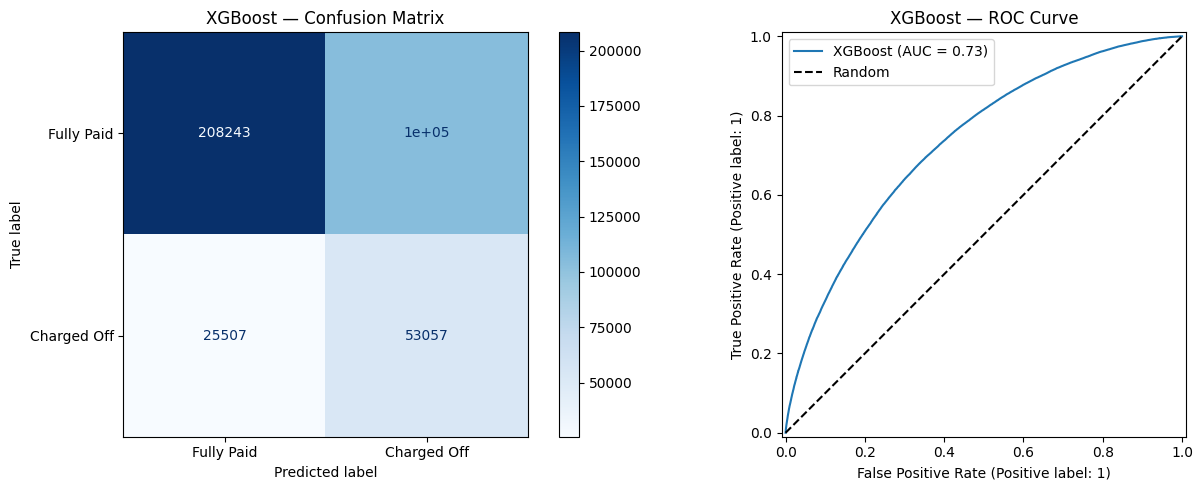

In [13]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid', 'Charged Off'])
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('XGBoost — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('xgb_evaluation.png', dpi=150)
plt.show()

## 8. Feature Importance

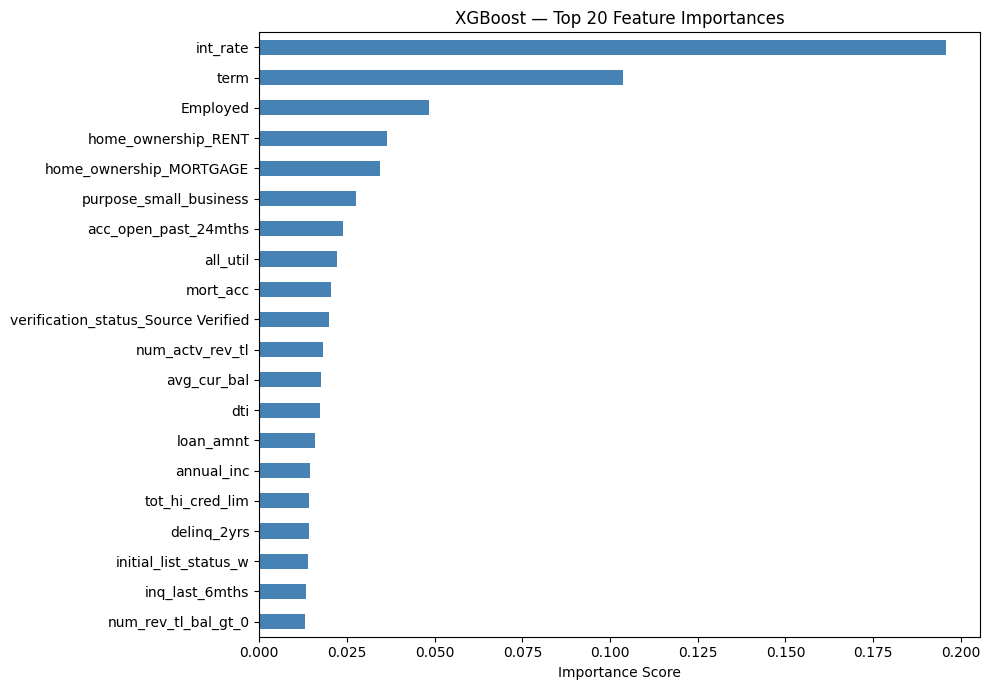


Top 10 features:
int_rate                               0.195663
term                                   0.103578
Employed                               0.048448
home_ownership_RENT                    0.036465
home_ownership_MORTGAGE                0.034433
purpose_small_business                 0.027468
acc_open_past_24mths                   0.023874
all_util                               0.022231
mort_acc                               0.020584
verification_status_Source Verified    0.019781
dtype: float32


In [14]:
# Reconstruct feature names after OHE
ohe_feature_names = encoder.get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(ohe_feature_names)

feat_imp = pd.Series(xgb_model.feature_importances_, index=all_feature_names)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('XGBoost — Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(top20.head(10))

## 9. Save Model

In [15]:
'''joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(encoder, 'xgb_encoder.pkl')
joblib.dump(scaler, 'xgb_scaler.pkl')
print("Model, encoder, scaler saved!")
'''

'joblib.dump(xgb_model, \'xgb_model.pkl\')\njoblib.dump(encoder, \'xgb_encoder.pkl\')\njoblib.dump(scaler, \'xgb_scaler.pkl\')\nprint("Model, encoder, scaler saved!")\n'

# Probability Calibration

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Platt Scaling (Sigmoid)
calibrated_sigmoid = CalibratedClassifierCV(
    xgb_model,  # your trained logistic model OR xgb_model
    method='sigmoid',
    cv=3
)

calibrated_sigmoid.fit(X_train_final, y_train)

# Isotonic Regression
calibrated_isotonic = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv=3
)

calibrated_isotonic.fit(X_train_final, y_train)

# Original
y_prob_orig = xgb_model.predict_proba(X_test_final)[:,1]

# Sigmoid calibrated
y_prob_sig = calibrated_sigmoid.predict_proba(X_test_final)[:,1]

# Isotonic calibrated
y_prob_iso = calibrated_isotonic.predict_proba(X_test_final)[:,1]

##### Calibration Curve

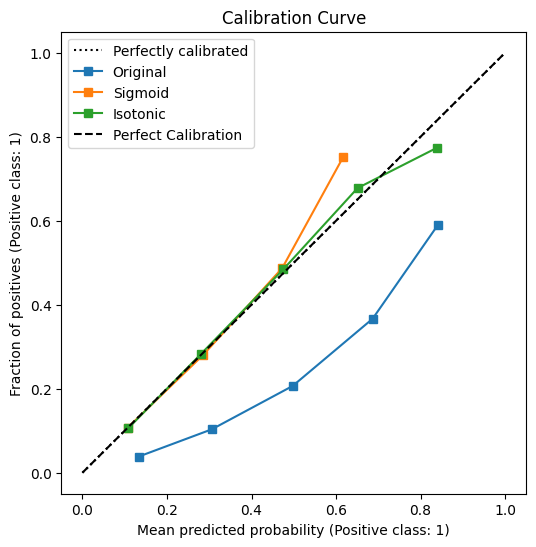

In [17]:
fig, ax = plt.subplots(figsize=(6,6))

CalibrationDisplay.from_predictions(y_test, y_prob_orig, name='Original', ax=ax)
CalibrationDisplay.from_predictions(y_test, y_prob_sig, name='Sigmoid', ax=ax)
CalibrationDisplay.from_predictions(y_test, y_prob_iso, name='Isotonic', ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
ax.set_title("Calibration Curve")
ax.legend()

plt.show()

In [18]:
y_pred_sig = (y_prob_sig >= 0.5).astype(int)

print(classification_report(y_test, y_pred_sig))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    312602
           1       0.60      0.10      0.17     78564

    accuracy                           0.81    391166
   macro avg       0.70      0.54      0.53    391166
weighted avg       0.77      0.81      0.74    391166



In [19]:
y_pred_iso = (y_prob_iso >= 0.5).astype(int)
print(classification_report(y_test, y_pred_iso))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    312602
           1       0.59      0.11      0.18     78564

    accuracy                           0.81    391166
   macro avg       0.70      0.54      0.54    391166
weighted avg       0.77      0.81      0.75    391166



In [20]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores_sig = []
f1_scores_iso = []

for t in thresholds:
    y_pred_sig = (y_prob_sig >= t).astype(int)
    y_pred_iso = (y_prob_iso >= t).astype(int)
    f1_scores_sig.append(f1_score(y_test, y_pred_sig))
    f1_scores_iso.append(f1_score(y_test, y_pred_iso))

best_threshold_sig = thresholds[np.argmax(f1_scores_sig)]
best_threshold_iso = thresholds[np.argmax(f1_scores_iso)]
best_f1_sig = max(f1_scores_sig)
best_f1_iso = max(f1_scores_iso)

print("Best threshold-sigmoid:", best_threshold_sig)
print("Best F1-score-sigmoid:", best_f1_sig)
print("Best threshold-isotonic:", best_threshold_iso)
print("Best F1-score-isotonic:", best_f1_iso)

Best threshold-sigmoid: 0.2306122448979592
Best F1-score-sigmoid: 0.45175557529571275
Best threshold-isotonic: 0.2306122448979592
Best F1-score-isotonic: 0.4517628091139721


In [21]:
X_test_with_prob = X_test_with_index.copy()
X_test_with_prob['predicted_prob'] = y_prob_iso

In [22]:
X_test_with_prob.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391166 entries, 941348 to 1512882
Data columns (total 59 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   391166 non-null  int64  
 1   term                        391166 non-null  int64  
 2   int_rate                    391166 non-null  float64
 3   installment                 391166 non-null  float64
 4   sub_grade                   391166 non-null  object 
 5   emp_length                  391166 non-null  float64
 6   home_ownership              391166 non-null  object 
 7   annual_inc                  391166 non-null  float64
 8   verification_status         391166 non-null  object 
 9   purpose                     391166 non-null  object 
 10  dti                         391166 non-null  float64
 11  delinq_2yrs                 391166 non-null  float64
 12  inq_last_6mths              391166 non-null  float64
 13  open_acc     

In [23]:
X_test_with_prob.to_csv("test_predictions.csv", index=False)

# csv file link
# https://drive.google.com/file/d/10FwLy34tDMePO75ldYlM4RDoATsLkPfh/view?usp=sharing